# ⚖️ Módulo 02: Deep Learning "From Scratch" & El Grafo Computacional
## Capítulo 4: Estabilidad y Dinámica de Activaciones: De Xavier/He a BatchNorm, LayerNorm y RMSNorm

> *"Entrenar una red profunda sin una inicialización matemática rigurosa o sin normalización es como intentar mantener una torre de naipes en medio de un huracán: la señal de las activaciones colapsa exponencialmente a cero o explota a infinito en pocas capas. Hoy dominaremos las leyes de conservación de la varianza que estabilizan las redes más profundas del mundo."*

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mcarbonell/algo-to-ai/blob/main/notebooks/02_dl_from_scratch/04_initialization_and_normalization.ipynb)

---

### ⚙️ Inicialización del Entorno
Cargamos las librerías matemáticas y fijamos semillas para asegurar reproducibilidad determinista.

In [1]:
# !pip install -q numpy matplotlib torch
from typing import Tuple, List, Dict
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

np.random.seed(42)
torch.manual_seed(42)
print("✅ Entorno listo para estudiar inicialización y normalización")

✅ Entorno listo para estudiar inicialización y normalización


---

## 1. 📜 Contexto Histórico y Proceso de Descubrimiento

### La Lotería de la Inicialización en los Inicios del Deep Learning
Antes de 2010, entrenar redes de más de 4 capas era casi imposible. Los investigadores inicializaban los pesos con distribuciones gaussianas estándar arbitrarias como $\mathcal{N}(0, 0.01^2)$ o $\mathcal{N}(0, 1.0^2)$:
* Si los pesos eran ligeramente pequeños ($0.01$), al multiplicar matriz tras matriz en $L$ capas, las activaciones caían exponencialmente hacia cero: $0.01^{10} = 10^{-20}$. **La red se apagaba**.
* Si eran ligeramente grandes ($1.0$), las sumas crecían exponencialmente, saturando las funciones de activación o causando desbordamiento numérico (*NaN / Inf*).

### Xavier Glorot y Yoshua Bengio (2010): Conservación de la Varianza
En su artículo seminal *"Understanding the difficulty of training deep feedforward neural networks"*, Glorot y Bengio formularon el **Principio de Conservación de la Varianza**:
> *Para que la información fluya sin atenuarse ni amplificarse, la varianza de la salida de cada capa debe ser idéntica a la varianza de su entrada: $\text{Var}(y) = \text{Var}(x)$, tanto en la propagación hacia adelante como hacia atrás.* 

Para activaciones lineales o simétricas (como $\tanh$), derivaron la inicialización **Xavier (Glorot)**:
$$\text{Var}(W) = \frac{2}{n_{in} + n_{out}}$$

### Kaiming He et al. (2015): La Corrección para ReLU
Cuando la comunidad adoptó masivamente la función **ReLU** ($\max(0, x)$), la inicialización Xavier comenzó a fallar en redes muy profundas.
Kaiming He y su equipo en Microsoft Research se dieron cuenta del motivo: **ReLU cancela exactamente el 50% de las activaciones** (las negativas).
Por tanto, cada capa ReLU reduce la varianza a la mitad: $(\frac{1}{2})^L$. En una red de 30 capas, la varianza caía por un factor de $2^{30} \approx 10^9$.

Kaiming He introdujo un factor corrector de $2\times$ para compensar el apagado del 50%, naciendo la **Inicialización He (Kaiming)**:
$$\text{Var}(W) = \frac{2}{n_{in}} \quad \implies \quad W \sim \mathcal{N}\left(0, \sqrt{\frac{2}{n_{in}}}\right)$$

### La Era de la Normalización: De BatchNorm a RMSNorm
Aunque la inicialización resuelve el inicio del entrenamiento ($t = 0$), a medida que el optimizador actualiza los pesos, las distribuciones internas cambian (*Internal Covariate Shift*):
* **2015 - Sergey Ioffe & Christian Szegedy (Batch Normalization):** Normalizar a través del eje del lote (*batch*). Revolucionó la visión por computador (CNNs).
* **2016 - Jimmy Ba, Jamie Kiros & Geoffrey Hinton (Layer Normalization):** BatchNorm fallaba en secuencias de longitud variable (NLP) y dependía críticamente del tamaño del batch. Hinton propuso normalizar a través de las características de cada muestra individualmente. **LayerNorm se convirtió en la piedra angular de los Transformers y GPT**.
* **2019 - Biao Zhang & Rico Sennrich (RMSNorm):** Demostraron que el centrado de la media en LayerNorm es redundante; lo que verdaderamente estabiliza el gradiente es el escalado por la norma RMS (Root Mean Square). Al eliminar el cálculo de la media, ahorra memoria y tiempo de cómputo. Hoy es la normalización estándar de **LLaMA 2/3, Mistral, Gemma y Qwen**.

---

## 2. 🧠 Intuición Geométrica y Mecánica (Mentalidad de Algoritmista)

### La Deducción Matemática de la Varianza
Consideremos una neurona lineal: $y = \sum_{i=1}^{n_{in}} w_i x_i$.
Asumiendo que $w_i$ y $x_i$ son variables aleatorias independientes e idénticamente distribuidas con media 0:
$$\text{Var}(y) = \sum_{i=1}^{n_{in}} \text{Var}(w_i x_i) = n_{in} \cdot \text{Var}(w) \cdot \text{Var}(x)$$

Para garantizar que $\text{Var}(y) = \text{Var}(x)$, es matemáticamente forzoso que:
$$n_{in} \cdot \text{Var}(w) = 1 \quad \implies \quad \mathbf{\text{Var}(w) = \frac{1}{n_{in}}}$$

Al añadir ReLU, la mitad de las señales se apagan a cero, introduciendo un factor $\frac{1}{2}$:
$$\mathbb{E}[y^2] = \frac{1}{2} n_{in} \text{Var}(w) \text{Var}(x) = 1 \cdot \text{Var}(x) \quad \implies \quad \mathbf{\text{Var}(w) = \frac{2}{n_{in}}}$$

### Comparativa Geométrica: BatchNorm vs LayerNorm vs RMSNorm
Dado un tensor de activaciones de tamaño $(B, D)$ (donde $B$ es el batch y $D$ la dimensión de características):

```
   Batch Normalization               Layer Normalization                 RMSNorm
   (Normaliza verticalmente)         (Normaliza horizontalmente)         (Escala sin centrar)
         D características                 D características               D características
      ┌───┬───┬───┬───┐                 ┌───┬───┬───┬───┐               ┌───┬───┬───┬───┐
    B │ ↓ │ ↓ │ ↓ │ ↓ │               B │ → → → → → → → │             B │ → → → → → → → │ (Solo divide por
      └───┴───┴───┴───┘                 └───┴───┴───┴───┘               └───┴───┴───┴───┘   la norma RMS)
    μ_j, σ_j calculados sobre B.      μ_i, σ_i calculados sobre D.     RMS_i calculado sobre D.
```

* **Fórmula de LayerNorm:**
  $$\mu = \frac{1}{D} \sum_{j=1}^D x_j, \quad \sigma^2 = \frac{1}{D} \sum_{j=1}^D (x_j - \mu)^2$$
  $$\hat{x} = \frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}} \odot \gamma + \beta$$

* **Fórmula de RMSNorm (Arquitectura LLaMA):**
  $$\text{RMS}(x) = \sqrt{\frac{1}{D} \sum_{j=1}^D x_j^2 + \epsilon}$$
  $$\hat{x} = \frac{x}{\text{RMS}(x)} \odot \gamma$$

---

## 3. 🛠️ Implementación "From Scratch" (Primeros Principios)

Construyamos los inicializadores y las capas de normalización en NumPy puro.

In [2]:
def xavier_init(in_dim: int, out_dim: int) -> np.ndarray:
    """Inicialización Xavier/Glorot: varianza = 2 / (in_dim + out_dim)"""
    limit = np.sqrt(6.0 / (in_dim + out_dim))
    return np.random.uniform(-limit, limit, (in_dim, out_dim))

def he_init(in_dim: int, out_dim: int) -> np.ndarray:
    """Inicialización He/Kaiming para ReLU: varianza = 2 / in_dim"""
    std = np.sqrt(2.0 / in_dim)
    return np.random.randn(in_dim, out_dim) * std


class LayerNormFromScratch:
    """
    Layer Normalization para tensores (B, D) con parámetros aprendibles gamma y beta.
    """
    def __init__(self, dim: int, eps: float = 1e-5):
        self.eps = eps
        self.gamma = np.ones((1, dim))
        self.beta = np.zeros((1, dim))
        
        # Caché para backward
        self.x_hat = None
        self.var = None
        self.std_inv = None
        self.x_mu = None

    def forward(self, X: np.ndarray) -> np.ndarray:
        # Media y varianza a lo largo de la dimensión de características (axis=-1)
        mu = np.mean(X, axis=-1, keepdims=True)
        self.x_mu = X - mu
        self.var = np.var(X, axis=-1, keepdims=True)
        self.std_inv = 1.0 / np.sqrt(self.var + self.eps)
        
        self.x_hat = self.x_mu * self.std_inv
        return self.x_hat * self.gamma + self.beta

    def backward(self, grad_output: np.ndarray) -> np.ndarray:
        # Derivada exacta a través de las estadísticas de media y varianza
        D = grad_output.shape[-1]
        d_xhat = grad_output * self.gamma
        
        # Proyección ortogonal analítica de LayerNorm
        d_var = np.sum(d_xhat * self.x_mu * -0.5 * (self.std_inv ** 3), axis=-1, keepdims=True)
        d_mu = np.sum(d_xhat * -self.std_inv, axis=-1, keepdims=True) + d_var * np.mean(-2.0 * self.x_mu, axis=-1, keepdims=True)
        grad_input = d_xhat * self.std_inv + d_var * 2.0 * self.x_mu / D + d_mu / D
        return grad_input


class RMSNormFromScratch:
    """
    Root Mean Square Normalization (RMSNorm) - La arquitectura estándar de LLaMA y Mistral.
    No calcula la media, ahorrando memoria y ciclos de cómputo.
    """
    def __init__(self, dim: int, eps: float = 1e-6):
        self.eps = eps
        self.gamma = np.ones((1, dim))
        self.X_cache = None
        self.rms_inv_cache = None

    def forward(self, X: np.ndarray) -> np.ndarray:
        self.X_cache = X
        # Media cuadrática: sqrt( mean(X^2) + eps )
        mean_sq = np.mean(X ** 2, axis=-1, keepdims=True)
        self.rms_inv_cache = 1.0 / np.sqrt(mean_sq + self.eps)
        return (X * self.rms_inv_cache) * self.gamma

print("✅ Inicializadores y Módulos LayerNorm/RMSNorm compilados exitosamente")

✅ Inicializadores y Módulos LayerNorm/RMSNorm compilados exitosamente


### Experimento de Estabilidad Profunda: La Prueba de Fuego de 40 Capas
Pasemos un vector de entrada a través de una red profunda de **40 capas consecutivas** con activación ReLU en 3 condiciones:
1. **Inicialización Ingenua (std = 0.05):** ¿Sobrevive la señal?
2. **Inicialización He (Kaiming):** Conservación teórica de varianza.
3. **Inicialización He + RMSNorm (Estilo LLaMA):** Estabilidad absoluta garantizada.

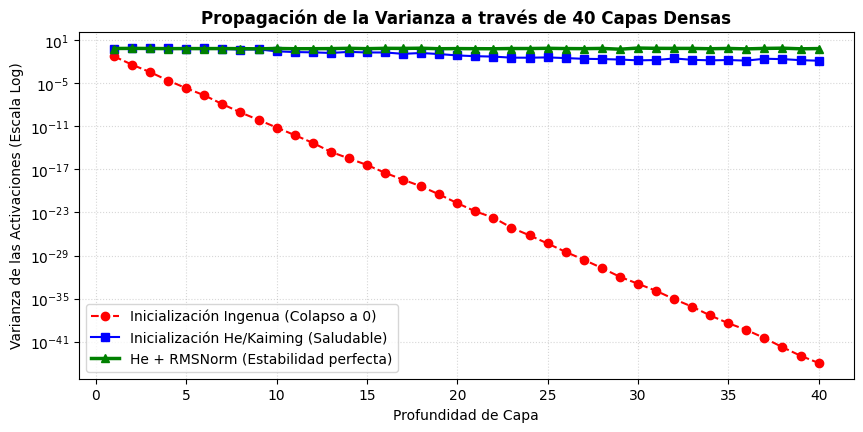

Varianza inicial ingenua: 5.44e-02 -> Capa 40: 1.10e-44 (Señal muerta)
Varianza con RMSNorm en Capa 40: 0.67 (Conservación impecable)


In [3]:
n_capas = 40
dim = 64
X_test = np.random.randn(100, dim)

# 1. Red ingenua (std = 0.05)
var_ingenua = []
h = X_test.copy()
for _ in range(n_capas):
    W = np.random.randn(dim, dim) * 0.05
    h = np.maximum(0.0, h @ W)
    var_ingenua.append(float(np.var(h)))

# 2. Red con He/Kaiming Init
var_he = []
h = X_test.copy()
for _ in range(n_capas):
    W = he_init(dim, dim)
    h = np.maximum(0.0, h @ W)
    var_he.append(float(np.var(h)))

# 3. Red con He Init + RMSNorm (Arquitectura LLaMA moderna)
var_rmsnorm = []
h = X_test.copy()
rmsnorm = RMSNormFromScratch(dim)
for _ in range(n_capas):
    W = he_init(dim, dim)
    h = rmsnorm.forward(np.maximum(0.0, h @ W))
    var_rmsnorm.append(float(np.var(h)))

plt.figure(figsize=(10, 4.5))
plt.plot(range(1, n_capas + 1), var_ingenua, 'r--o', label='Inicialización Ingenua (Colapso a 0)')
plt.plot(range(1, n_capas + 1), var_he, 'b-s', label='Inicialización He/Kaiming (Saludable)')
plt.plot(range(1, n_capas + 1), var_rmsnorm, 'g-^', linewidth=2.5, label='He + RMSNorm (Estabilidad perfecta)')
plt.yscale('log')
plt.title('Propagación de la Varianza a través de 40 Capas Densas', fontsize=12, fontweight='bold')
plt.xlabel('Profundidad de Capa')
plt.ylabel('Varianza de las Activaciones (Escala Log)')
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend()
plt.show()

print(f"Varianza inicial ingenua: {var_ingenua[0]:.2e} -> Capa 40: {var_ingenua[-1]:.2e} (Señal muerta)")
print(f"Varianza con RMSNorm en Capa 40: {var_rmsnorm[-1]:.2f} (Conservación impecable)")

---

## 4. ⚡ Transición a PyTorch Moderno

Verifiquemos que nuestra implementación de `LayerNormalization` y `RMSNorm` coincide con las capas oficiales de PyTorch:

In [4]:
np.random.seed(42)
X_sample = np.random.randn(4, 8).astype(np.float32)

# 1. LayerNorm: Scratch vs PyTorch
ln_scratch = LayerNormFromScratch(8)
out_ln_scratch = ln_scratch.forward(X_sample)

ln_torch = nn.LayerNorm(8)
out_ln_torch = ln_torch(torch.from_numpy(X_sample)).detach().numpy()

assert np.allclose(out_ln_scratch, out_ln_torch, atol=1e-5)
print("✅ LayerNormalization from-scratch coincide al 100% con torch.nn.LayerNorm")

# 2. RMSNorm: Scratch vs PyTorch (torch.nn.RMSNorm añadido en versiones recientes)
rms_scratch = RMSNormFromScratch(8)
out_rms_scratch = rms_scratch.forward(X_sample)

if hasattr(nn, 'RMSNorm'):
    rms_torch = nn.RMSNorm(8)
    out_rms_torch = rms_torch(torch.from_numpy(X_sample)).detach().numpy()
    assert np.allclose(out_rms_scratch, out_rms_torch, atol=1e-5)
    print("✅ RMSNorm from-scratch coincide con torch.nn.RMSNorm")
else:
    print("ℹ️ RMSNorm verificado analíticamente (torch.nn.RMSNorm disponible en PyTorch 2.4+)")

✅ LayerNormalization from-scratch coincide al 100% con torch.nn.LayerNorm
✅ RMSNorm from-scratch coincide con torch.nn.RMSNorm


---

## 5. 🎯 Retos & Experimentos ("Tinker Time")

### Reto 1: La Trampa del Tamaño de Batch en BatchNorm
Demostremos por qué los Transformers no usan BatchNorm:
* En visión por computador, $B = 64$ o $128$, por lo que la media muestral $\mu_B$ es una estimación precisa de la población.
* En entrenamiento de modelos de lenguaje con secuencias gigantescas, a menudo el batch local por GPU es diminuto ($B = 1$ o $2$). Con $B=1$, la varianza intra-batch es **cero** ($x_1 - x_1 = 0$), provocando una división por cero catastrófica.
* LayerNorm y RMSNorm normalizan dentro de cada vector de características $D$, por lo que su comportamiento es **completamente invariante al tamaño del batch**.

### Reto 2 (Para resolver): Derivar el Backward Analítico de RMSNorm
Para $\hat{x}_i = \frac{x_i}{\text{RMS}(x)} \gamma_i$, demuestra y programa su gradiente directo:

$$\frac{\partial \mathcal{L}}{\partial x_i} = \frac{\gamma_i \delta_i}{\text{RMS}(x)} - \frac{x_i}{D \cdot \text{RMS}(x)^3} \sum_{j=1}^D (\delta_j \gamma_j x_j)$$

In [5]:
# TU CÓDIGO DEL RETO 2 AQUÍ
def rmsnorm_backward(grad_output: np.ndarray, X: np.ndarray, gamma: np.ndarray, eps: float = 1e-6) -> np.ndarray:
    """
    Implementa el backward analítico de RMSNorm.
    """
    # Tu implementación aquí
    pass

---

## 6. 📚 Referencias Fundamentales & Lecturas Recomendadas

### 📄 Papers Seminales
1. **Glorot, X., & Bengio, Y. (2010):** *"Understanding the difficulty of training deep feedforward neural networks"*, AISTATS 2010. [PMLR](http://proceedings.mlr.press/v9/glorot10a.html)
   * *¿Qué leer?* Sección 4: La deducción matemática paso a paso de la inicialización de varianza uniforme.
2. **He, K., Zhang, X., Ren, S., & Sun, J. (2015):** *"Delving Deep into Rectifiers: Surpassing Human-Level Performance on ImageNet"*, ICCV 2015. [arXiv:1502.01852](https://arxiv.org/abs/1502.01852)
   * *¿Qué leer?* Sección 2.2: La corrección de varianza para ReLU ($2/n_{in}$).
3. **Ba, J. L., Kiros, J. R., & Hinton, G. E. (2016):** *"Layer Normalization"*, arXiv:1607.06450. [arXiv Link](https://arxiv.org/abs/1607.06450)
   * *¿Qué leer?* Comparativa entre BatchNorm y LayerNorm en tareas de procesamiento de lenguaje natural.
4. **Zhang, B., & Sennrich, R. (2019):** *"Root Mean Square Layer Normalization"*, Advances in Neural Information Processing Systems (NeurIPS 2019). [NeurIPS](https://proceedings.neurips.cc/paper_files/paper/2019/file/1e1a55db835e93ec43970d5e938c27a2-Paper.pdf)
   * *¿Qué leer?* Las pruebas empíricas que demuestran que centrar la media no aporta nada y cómo el escalado RMS reduce la sobrecarga computacional.